In [1]:
import h5py
import psana
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import  rotate
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit,minimize
from matplotlib.backends.backend_pdf import PdfPages
import multiprocessing
import os
from functools import partial
import time
import sys
import argparse
from datetime import datetime
import tempfile
import XSpect.XSpect_Analysis
import XSpect.XSpect_Controller
import XSpect.XSpect_Visualization
import XSpect.XSpect_Diagnostics as dt
import XSpect.XSpect_PostProcessing

Run 55 imported


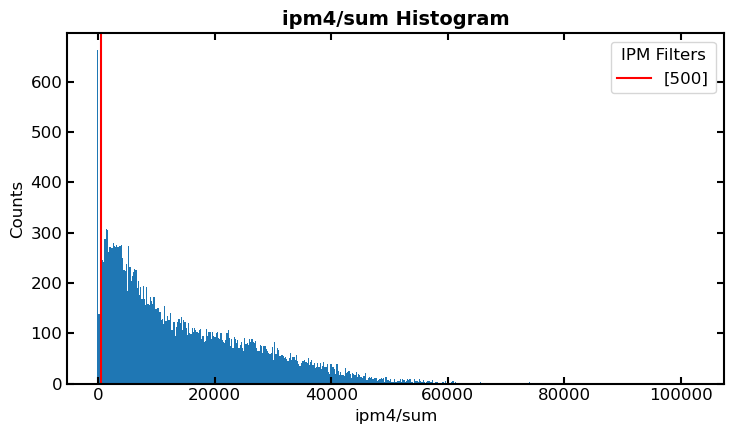

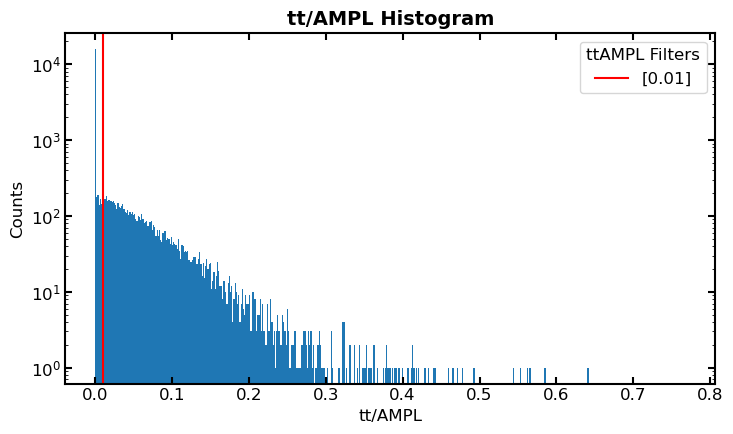

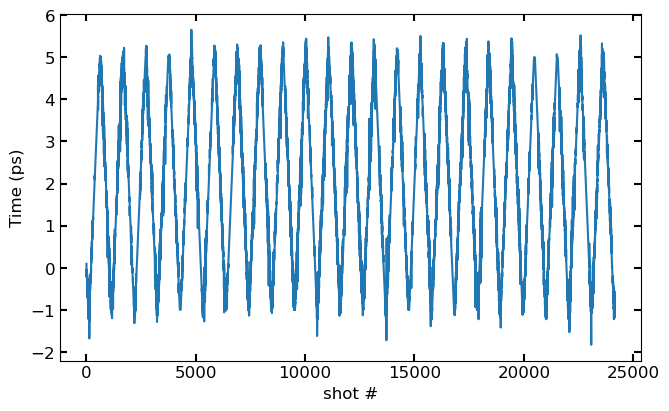

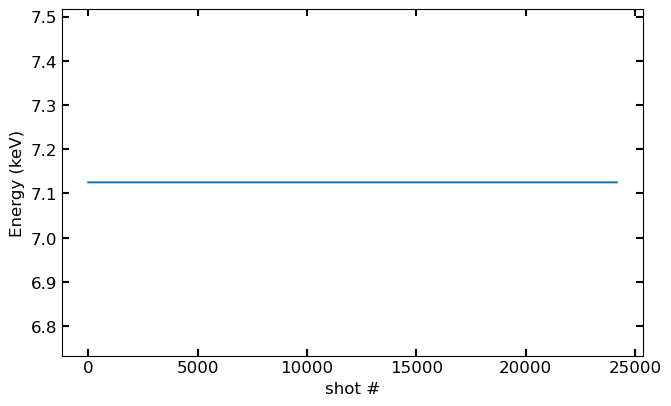

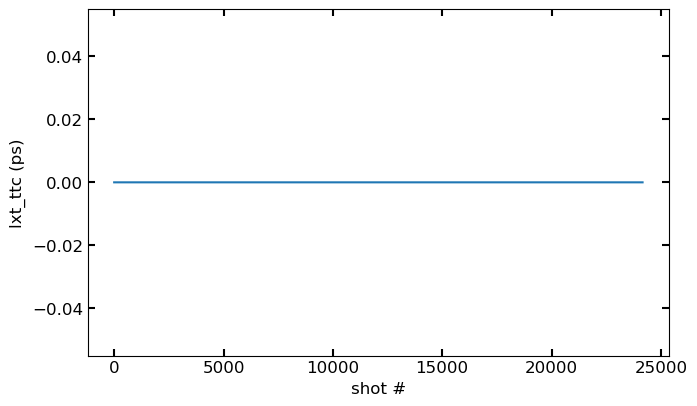

In [2]:
run = 55
exp = 'xcs101632226'
keys=['epicsUser/dccm_E', 'epicsUser/dccm_E_setpoint', 'tt/ttCorr','epics/lxt', 'enc/lasDelay' , 'ipm4/sum','tt/AMPL'] 
names=['energy','energy_E_setpoint','time_tool_correction','lxt_ttc'  ,'encoder','ipm', 'time_tool_ampl']

# pdf = PdfPages("output.pdf")

d = dt.diagnostics(run, exp, keys, names)

ipm_thres = [500]

d.ipm_histogram(ipm_thres)

# figx = plt.gcf()
# pdf.savefig(figx)

tt_thres = [0.01]

d.ttAMPL_histogram(tt_thres)

# d.droplet_histogram()

nshots = 1000

# adu_thres = [3.5]
# d.adu_histogram(nshots, adu_thres)

# ka_roi_d = [270, 300]
# kb_roi_d = [180, 220]

# d.detector_sum_ROI(ka_roi_d, kb_roi_d)
# ka_roi = [100, 120]
# kb_roi = [15, 55]
# 
# d.xes_ROI(nshots, ka_limits = ka_roi, kb_limits = kb_roi, angle = 0)

# d.xes_ROI(nshots, ka_limits = ka_roi, kb_limits = kb_roi, angle = 1.4)

# delay = d.h5[d.datadict['time_tool_correction']][:] + d.h5[d.datadict['lxt_ttc']][:]*1e12 + d.h5[d.datadict['encoder']][:]
delay = d.h5[d.datadict['time_tool_correction']][:] + d.h5[d.datadict['encoder']][:]

plt.plot(delay)
plt.ylabel('Time (ps)')
plt.xlabel('shot #')
plt.show()

plt.plot(d.h5['epicsUser']['dccm_E_setpoint'][:])
plt.xlabel('shot #')
plt.ylabel('Energy (keV)')
plt.show()

plt.plot(d.h5[d.datadict['lxt_ttc']][:]*1e12)
plt.xlabel('shot #')
plt.ylabel('lxt_ttc (ps)')
plt.show()
# pdf.close()

### XANES 1D Time

In [3]:
start = time.time()

xspect_experiment = XSpect.XSpect_Analysis.spectroscopy_experiment(hutch='xcs',experiment_id=exp,lcls_run=exp[-2:])
xes1=XSpect.XSpect_Controller.XASBatchAnalysis_1D_time()
keys=['epicsUser/dccm_E', 'epicsUser/dccm_E_setpoint', 'tt/ttCorr','epics/lxt', 'enc/lasDelay' , 'ipm4/sum','tt/AMPL', 'epix_2/ROI_sum'] 
names=['energy','energy_E_setpoint','time_tool_correction','lxt_ttc'  ,'encoder','ipm', 'time_tool_ampl', 'epix']

#Here we define the epix detector keys separately as they are imported separately to avoid OOM
# xes1.key_epix=['epix_2/ROI_sum']
# xes1.friendly_name_epix=['epix']

##

# xes1.mintime = -0.75 # ps
# xes1.maxtime = 1 # ps
xes1.mintime = -1 # ps
xes1.maxtime = 5 # ps
xes1.time_step = 0.1 # ps
xes1.time_bins  = np.arange(xes1.mintime, xes1.maxtime+xes1.time_step, xes1.time_step)

xes1.set_key_aliases(keys,names)

xes1.transpose=False
xes1.add_filter('xray','ipm',ipm_thres[0])
xes1.add_filter('simultaneous','ipm',ipm_thres[0])
xes1.add_filter('simultaneous','time_tool_ampl',tt_thres[0])
xes1.scattering = True

# xes1.run_parser(['230-232']) #
xes1.run_parser(['55']) #

/sdf/data/lcls/ds/xcs/xcs101632226/results/XSpect/XSpect/XSpect_Controller.py:126: UserWarning: If you plan on using delayed key loading for the epix then please define key_epix and friendly_name_epix. And do not load it here for risk of OOM
  warnings.warn('If you plan on using delayed key loading for the epix then please define key_epix and friendly_name_epix. And do not load it here for risk of OOM')


In [4]:
start=time.time()

xes1.primary_analysis_loop(xspect_experiment, verbose = True)

end=time.time()
print('Analysis completed: %.02f s' % (end - start))

Obtained shot properties
HDF5 import of keys completed. Time: 0.00 seconds
------Timing data values are either very small or zero. Confirm the units and keys are correct-----
-----Mean abs value of: lxt_key: 0.000000, fast_delay: 2.226561, tt_correction: 0.053780 -----
Generated timing bins from -1.000000 to 5.000000 in 61 steps.
Mask: xray has been filtered on ipm by minimum threshold: 500.000
Shots removed: 1073
Mask: simultaneous has been filtered on ipm by minimum threshold: 500.000
Shots removed: 770
Mask: simultaneous has been filtered on time_tool_ampl by minimum threshold: 0.010
Shots removed: 8911
Mask: xray has been filtered on delays by minimum threshold: -1.050 and maximum threshold: 5.050
Shots removed: 347
Mask: simultaneous has been filtered on delays by minimum threshold: -1.050 and maximum threshold: 5.050
Shots removed: 283
Shots (7171) combined for detector epix on filters: simultaneous and laser into epix_simultaneous_laser
Shots (6551) separated for detector epix o

/sdf/group/lcls/ds/ana/sw/conda1/inst/envs/ana-4.0.68-py3/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


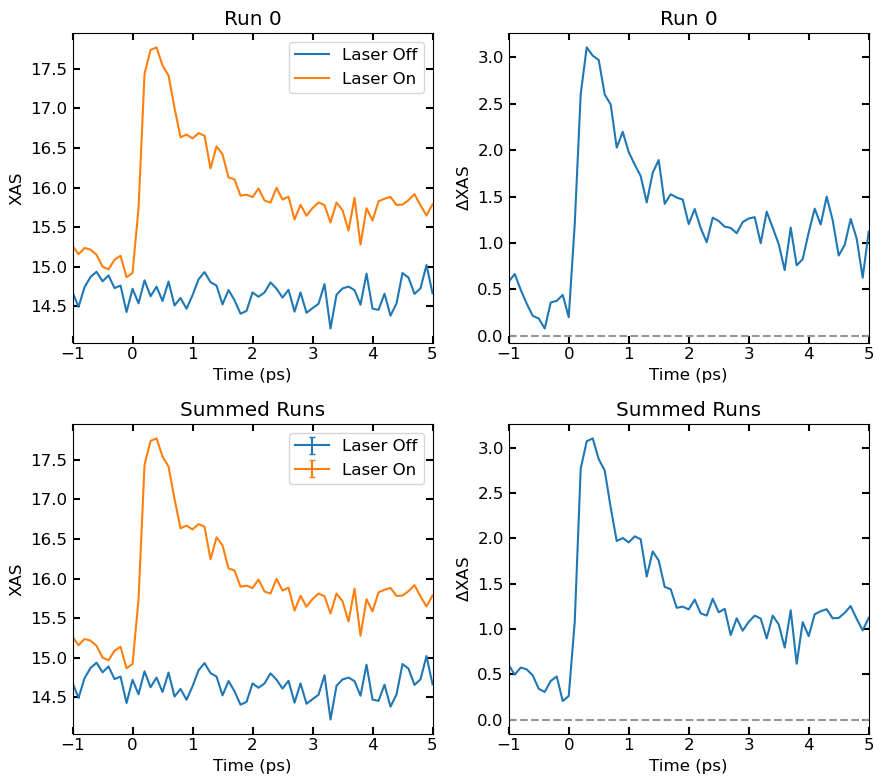

In [5]:
run_count = 0
for ii, run in enumerate(xes1.analyzed_runs):
    # print(ii)
    # print(run.ccm_bins.shape)
    # print(run.epix_simultaneous_laser_energy_binned.shape)
    # print(run.epix_xray_not_laser_energy_binned.shape)
    run_count+=1

fig, ax = plt.subplots(figsize = (9,8), nrows = run_count+1, ncols = 2)

# xas_loff_sum = np.zeros_like(xes1.analyzed_runs[0].epix_xray_not_laser_time_binned)
# xas_lon_sum = np.zeros_like(xes1.analyzed_runs[0].epix_simultaneous_laser_time_binned)

xas_loff_all = []
xas_lon_all  = []

for ii, run in enumerate(xes1.analyzed_runs):
    xas_loff_norm = run.epix_xray_not_laser_time_binned/run.ipm_xray_not_laser_time_binned
    xas_loff_norm_mean = np.ones_like(xas_loff_norm)*np.nanmean(xas_loff_norm)
    xas_lon_norm = run.epix_simultaneous_laser_time_binned/run.ipm_simultaneous_laser_time_binned
    xas_diff_norm = np.subtract(xas_lon_norm, xas_loff_norm)

    plt_indx0 = (ii,0)
    plt_indx1 = (ii,1)

    xas_loff_all.append(xas_loff_norm)
    xas_lon_all.append(xas_lon_norm)

    ax[plt_indx0].plot(run.time_bins, xas_loff_norm, label = 'Laser Off')
    ax[plt_indx0].plot(run.time_bins, xas_lon_norm, label = 'Laser On')
    ax[plt_indx0].set_xlim([np.min(run.time_bins), np.max(run.time_bins)])
    ax[plt_indx0].set_xlabel('Time (ps)')
    ax[plt_indx0].set_ylabel('XAS')
    ax[plt_indx0].legend()
    ax[plt_indx0].set_title('Run %i' % ii)

    ax[plt_indx1].plot(run.time_bins, xas_diff_norm, label = 'Difference')
    ax[plt_indx1].axhline(0, color = np.array([150,150,150])/255, linestyle = '--')
    ax[plt_indx1].set_xlim([np.min(run.time_bins), np.max(run.time_bins)])
    ax[plt_indx1].set_xlabel('Time (ps)')
    ax[plt_indx1].set_ylabel(r'$\Delta$XAS')
    ax[plt_indx1].set_title('Run %i' % ii)
    
    # xas_loff_sum += xas_loff_norm
    # xas_lon_sum += xas_lon_norm

xas_loff_all = np.array(xas_loff_all)
xas_lon_all  = np.array(xas_lon_all)

xas_loff_sum = np.nanmean(xas_loff_all, axis = 0)
xas_lon_sum = np.nanmean(xas_lon_all, axis = 0)

N = xas_loff_all.shape[0]

xas_loff_sem = np.nanstd(xas_loff_all, axis=0, ddof=1)/np.sqrt(N)
xas_lon_sem  = np.nanstd(xas_lon_all, axis=0, ddof=1)/np.sqrt(N)

xas_loff_sumtotal = np.ones_like(xas_loff_norm)*np.nanmean(xas_loff_sum)
xas_diff_sum = np.subtract(xas_lon_sum, xas_loff_sumtotal)
xas_diff_sem  = np.sqrt(xas_loff_sem**2 + xas_lon_sem**2)

plt_indx0_sum = (ii+1,0)
plt_indx1_sum = (ii+1,1)

ax[plt_indx0_sum].errorbar(run.time_bins, xas_loff_sum,
                           yerr=xas_loff_sem,
                           label='Laser Off',
                           capsize=2)

ax[plt_indx0_sum].errorbar(run.time_bins, xas_lon_sum,
                           yerr=xas_lon_sem,
                           label='Laser On',
                           capsize=2)

# ax[plt_indx0_sum].plot(run.time_bins, xas_loff_sumtotal, label = 'Laser Off')
# ax[plt_indx0_sum].plot(run.time_bins, xas_lon_sum, label = 'Laser On')
ax[plt_indx0_sum].set_xlim([np.min(run.time_bins), np.max(run.time_bins)])
ax[plt_indx0_sum].set_xlabel('Time (ps)')
ax[plt_indx0_sum].set_ylabel('XAS')
ax[plt_indx0_sum].legend()
ax[plt_indx0_sum].set_title('Summed Runs')

ax[plt_indx1_sum].errorbar(run.time_bins, xas_diff_sum,
                           yerr=xas_diff_sem,
                           label='Difference',
                           capsize=2)
# ax[plt_indx1_sum].plot(run.time_bins, xas_diff_sum, label = 'Difference')
# ax[plt_indx1_sum].axvline(0.15, color = 'r', linestyle = '--')
ax[plt_indx1_sum].axhline(0, color = np.array([150,150,150])/255, linestyle = '--')
ax[plt_indx1_sum].set_xlim([np.min(run.time_bins), np.max(run.time_bins)])
# ax[plt_indx1_sum].axvline(1, color = np.array([150,150,150])/255, linestyle = '--')
ax[plt_indx1_sum].set_xlabel('Time (ps)')
ax[plt_indx1_sum].set_ylabel(r'$\Delta$XAS')
ax[plt_indx1_sum].set_title('Summed Runs')

plt.tight_layout()

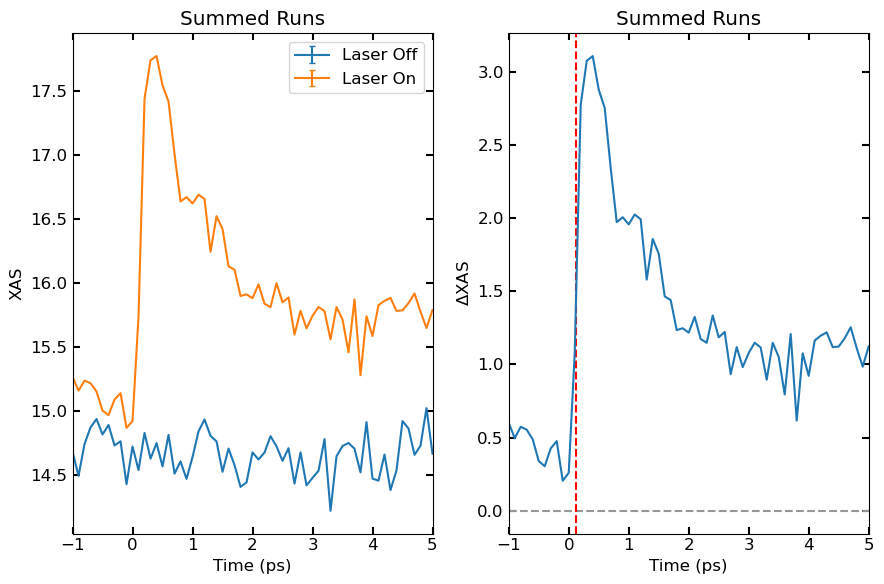

In [15]:
fig, ax = plt.subplots(figsize = (9,6), nrows = 1, ncols = 2)

ax[0].errorbar(run.time_bins, xas_loff_sum,
                           yerr=xas_loff_sem,
                           label='Laser Off',
                           capsize=2)

ax[0].errorbar(run.time_bins, xas_lon_sum,
                           yerr=xas_lon_sem,
                           label='Laser On',
                           capsize=2)
ax[0].set_xlim([np.min(xes1.time_bins), np.max(xes1.time_bins)])
ax[0].set_xlabel('Time (ps)')
ax[0].set_ylabel('XAS')
ax[0].legend()
ax[0].set_title('Summed Runs')

ax[1].errorbar(run.time_bins, xas_diff_sum,
                           yerr=xas_diff_sem,
                           label='Difference',
                           capsize=2)
ax[1].axhline(0, color = np.array([150,150,150])/255, linestyle = '--')
ax[1].set_xlim([np.min(xes1.time_bins), np.max(xes1.time_bins)])
ax[1].axvline(0.120, color = 'r', linestyle = '--')
ax[1].set_xlabel('Time (ps)')
ax[1].set_ylabel(r'$\Delta$XAS')
ax[1].set_title('Summed Runs')

plt.tight_layout()

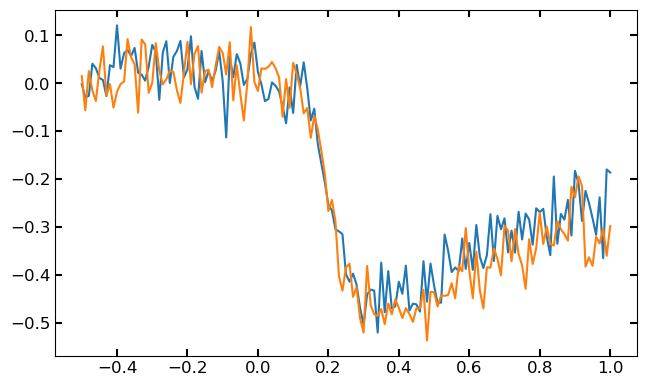

In [19]:
plt.plot(xes1.time_bins, xas_diff_sum)
plt.plot(xes1.time_bins, diff1)

In [324]:
# output_array = np.column_stack((
#     run.time_bins,
#     xas_loff_sumtotal,
#     xas_lon_sum,
#     xas_diff_sum
# ))

# # Save to txt
# np.savetxt(
#     'summed_run_7126_n2q_1.txt',
#     output_array,
#     header='Time_ps\tLaser_Off\tLaser_On\tDifference',
#     fmt='%.6e',
#     delimiter='\t'
# )